In [44]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import warnings
import pandas as pd
import gc
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams['font.size'] = 16         
plt.rcParams['axes.titlesize'] = 16   
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = "lower"
plt.rcParams['image.cmap'] = 'magma'

In [3]:
storage_folder = '/net/vdesk/data2/deklerk/GAAP_data/flux_files'
processed_file = "/net/vdesk/data2/deklerk/GAAP_data/processed.txt"

In [15]:
with open(processed_file, "r") as f:
    processed = set(line.strip() for line in f)
print(processed)

{'102018671', '102019587', '102019596', '102018667', '102019131', '102019590', '102019595', '102018664', '102019594', '102018669', '102019589', '102018665', '102019130', '102019588', '102018666', '102020056', '102019126', '102020060', '102019128', '102018670', '102020058', '102020057', '102019129', '102018213', '102019127', '102019585', '102019122', '102018668', '102018211', '102019592', '102020061', '102020055', '102020059', '102020054', '102019593', '102019123', '102019124', '102019125', '102018212', '102020053', '102019586', '102019591'}


In [45]:
gc.collect()

5246

In [60]:
all_fluxes = None
stop_index = 50
for i, tile_index in enumerate(processed):
    if i > stop_index:
        break
    if all_fluxes is None:
        all_fluxes = pd.read_csv(f'{storage_folder}/{tile_index}_fluxes.csv')
    else:
        fluxes = pd.read_csv(f'{storage_folder}/{tile_index}_fluxes.csv')
        all_fluxes = pd.concat([all_fluxes, fluxes], ignore_index=True)

In [67]:
print(len(all_fluxes))
all_fluxes

3426635


,id,ra,dec,DES-Z,DES-Z_sigma,DES-R,DES-R_sigma,DES-I,DES-I_sigma,DES-G,DES-G_sigma,NIR-H,NIR-H_sigma,NIR-J,NIR-J_sigma,NIR-Y,NIR-Y_sigma,VIS,VIS_sigma
0,-617074771507879352,61.707477,-50.787935,2451.113894,808.211945,715.488901,290.208906,1804.652673,4.256006e+02,127.611212,227.466816,0.000000,3.164358e+18,0.000000,2.897510e+18,0.000000,2.473571e+18,761.759278,8.008608e+19
1,-617059399507878014,61.705940,-50.787801,2018.671580,807.497166,1036.419770,289.641272,1740.630323,4.454564e+02,367.373048,227.386644,0.000000,3.163796e+18,0.000000,2.896760e+18,0.000000,2.472895e+18,1310.156332,2.569803e+19
2,-617509937507873391,61.750994,-50.787339,3248.340932,783.628532,546.190982,259.843296,1342.865073,3.956164e+02,98.130258,220.434191,0.000000,3.164295e+18,0.000000,2.897948e+18,0.000000,2.473480e+18,457.695695,1.257511e+20
3,-617477943507868478,61.747794,-50.786848,673.106768,773.624963,460.127822,260.578185,526.465867,3.950358e+02,371.310685,220.281638,0.000000,3.162511e+18,0.000000,2.895742e+18,0.000000,2.471331e+18,442.671819,4.352118e+19
4,-617214650507867293,61.721465,-50.786729,353.528769,762.339200,137.700483,259.483289,32.055938,3.776818e+02,71.419570,208.015260,0.000000,3.165534e+18,0.000000,2.898635e+18,0.000000,2.474995e+18,132.915581,1.903948e+19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3426630,-599581359497463428,59.958136,-49.746343,1132.815380,747.359516,376.551987,306.993689,681.456811,1.353417e+13,351.488160,269.273682,903.739846,4.638867e+02,613.901003,NaN,146.107999,5.306629e+02,357.458548,5.094653e+01
3426631,-600627447497464176,60.062745,-49.746418,228.579503,718.321014,-50.145367,279.222556,-132.565350,4.088365e+02,-79.369720,247.198650,826.667904,4.676031e+02,628.405117,4.697441e+02,838.713668,5.354264e+02,-8.036743,5.362349e+01
3426632,-598261616497459345,59.826162,-49.745935,-152.270454,716.050177,156.949233,287.979606,132.226959,4.068224e+02,30.718240,242.489696,305.278130,4.478809e+02,495.102591,4.522620e+02,316.277136,5.256494e+02,151.738813,5.218836e+01
3426633,-601135393497459963,60.113539,-49.745996,287.615294,769.398989,42.468944,305.922658,-105.268339,4.373004e+02,17.722769,257.627671,643.331294,4.998936e+02,174.808754,4.810899e+02,237.925634,5.646659e+02,36.243442,5.146338e+01


In [ ]:
all_fluxes.columns

Index(['id', 'ra', 'dec', 'DES-Z', 'DES-Z_sigma', 'DES-R', 'DES-R_sigma',
       'DES-I', 'DES-I_sigma', 'DES-G', 'DES-G_sigma', 'NIR-H', 'NIR-H_sigma',
       'NIR-J', 'NIR-J_sigma', 'NIR-Y', 'NIR-Y_sigma', 'VIS', 'VIS_sigma'],
      dtype='str')

10492


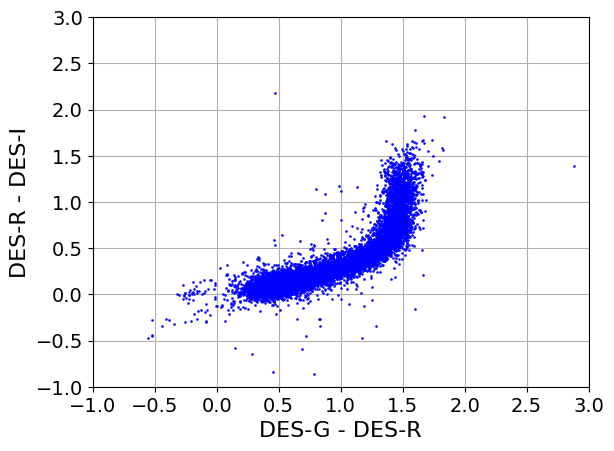

In [ ]:
filter_1 = 'DES-G'   # e.g., master_table column name
filter_2 = 'DES-R'
filter_3 = 'DES-R'
filter_4 = 'DES-I'

plot_error = True

# Compute colors from master_table fluxes
x_color = -2.5 * np.log10(all_fluxes[filter_1] / all_fluxes[filter_2])
y_color = -2.5 * np.log10(all_fluxes[filter_3] / all_fluxes[filter_4])

# Compute errors from sigma dictionary
xerr = 2.5 / np.log(10) * np.sqrt(
    (all_fluxes[f'{filter_1}_sigma'] / all_fluxes[filter_1])**2 +
    (all_fluxes[f'{filter_2}_sigma'] / all_fluxes[filter_2])**2
)
yerr = 2.5 / np.log(10) * np.sqrt(
    (all_fluxes[f'{filter_3}_sigma'] / all_fluxes[filter_3])**2 +
    (all_fluxes[f'{filter_4}_sigma'] / all_fluxes[filter_4])**2
)

gaap_error = xerr**2 + yerr**2
mask = (gaap_error < .0001)
plt.errorbar(
    x_color[mask], y_color[mask],
    xerr=xerr[mask] * plot_error, yerr=yerr[mask] * plot_error,
    fmt='o', c='b', ms=1, elinewidth=0.5, alpha=0.8, label='GAAP', rasterized=True
)
print(np.sum(mask))

plt.xlabel(f'{filter_1} - {filter_2}')
plt.ylabel(f'{filter_3} - {filter_4}')
plt.xlim(-1, 3)
plt.ylim(-1, 3)
plt.grid(True)
plt.show()